In [1]:
# Cell 1: Import Libraries

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA

# Qiskit - Quantum computing
import qiskit  # Add this line!
from qiskit import QuantumCircuit
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC, QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# For quantum simulation
from qiskit_aer import AerSimulator

print("✅ All libraries imported successfully!")
print(f"Qiskit version: {qiskit.__version__}")

✅ All libraries imported successfully!
Qiskit version: 2.3.0


In [3]:
# Cell 2: Load Data
print("Loading preprocessed data from Week 2...")

X_train = np.load('../data/X_train.npy')
X_val = np.load('../data/X_val.npy')
X_test = np.load('../data/X_test.npy')

y_train = np.load('../data/y_train.npy')
y_val = np.load('../data/y_val.npy')
y_test = np.load('../data/y_test.npy')

print(f"✅ Data loaded!")
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nOriginal features: {X_train.shape[1]}")

Loading preprocessed data from Week 2...
✅ Data loaded!
Training set: (26153, 4)
Validation set: (5604, 4)
Test set: (5605, 4)

Original features: 4



REDUCING FEATURES WITH PCA

Reducing from 4 features to 2 features...

✅ PCA complete!
New training shape: (26153, 2)
Explained variance ratio: [0.45184519 0.2532715 ]
Total variance retained: 70.51%


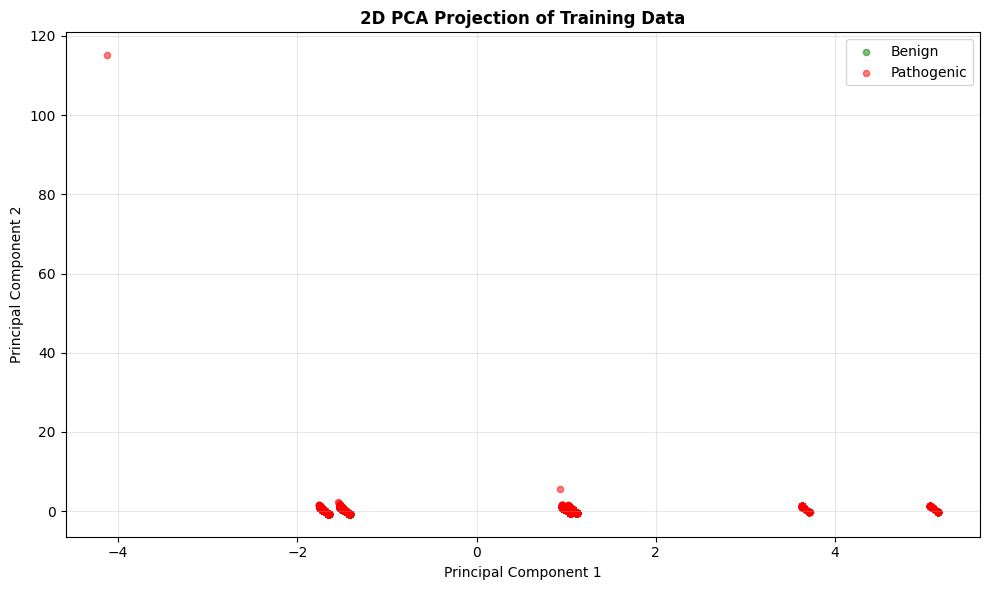


✅ PCA transformer saved!


In [4]:
# Cell 3: Dimensionality Reduction with PCA
print("\n" + "=" * 60)
print("REDUCING FEATURES WITH PCA")
print("=" * 60)

# Quantum works best with 2 features (much faster!)
n_quantum_features = 2

print(f"\nReducing from {X_train.shape[1]} features to {n_quantum_features} features...")

# Initialize PCA
pca = PCA(n_components=n_quantum_features, random_state=42)

# Fit on training data only (prevent leakage!)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"\n✅ PCA complete!")
print(f"New training shape: {X_train_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.2%}")

# Visualize the reduced feature space
plt.figure(figsize=(10, 6))
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], 
            alpha=0.5, label='Benign', c='green', s=20)
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], 
            alpha=0.5, label='Pathogenic', c='red', s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection of Training Data', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/pca_projection.png', dpi=300, bbox_inches='tight')
plt.show()

# Save PCA for later use
with open('../models/pca_transformer.pkl', 'wb') as f:
    pickle.dump(pca, f)
print("\n✅ PCA transformer saved!")

In [5]:
# Cell 4: Create Small Training Set for Quantum
print("\n" + "=" * 60)
print("CREATING SMALL DATASET FOR QUANTUM TRAINING")
print("=" * 60)

# Quantum is SLOW - start with small dataset
quantum_train_size = 500
quantum_test_size = 500

# Random sample from training set (stratified)
from sklearn.model_selection import train_test_split

# Use stratified sampling to maintain class balance
X_train_quantum, _, y_train_quantum, _ = train_test_split(
    X_train_pca, y_train, 
    train_size=quantum_train_size, 
    stratify=y_train,
    random_state=42
)

X_test_quantum, _, y_test_quantum, _ = train_test_split(
    X_test_pca, y_test, 
    train_size=quantum_test_size, 
    stratify=y_test,
    random_state=42
)

print(f"\n📊 Quantum Training Set:")
print(f"  Shape: {X_train_quantum.shape}")
print(f"  Benign: {(y_train_quantum == 0).sum()}")
print(f"  Pathogenic: {(y_train_quantum == 1).sum()}")

print(f"\n📊 Quantum Test Set:")
print(f"  Shape: {X_test_quantum.shape}")
print(f"  Benign: {(y_test_quantum == 0).sum()}")
print(f"  Pathogenic: {(y_test_quantum == 1).sum()}")

print("\n⚠️  NOTE: Using small dataset because quantum training is VERY slow!")
print("   Expected training time: 30-60 minutes per model")


CREATING SMALL DATASET FOR QUANTUM TRAINING

📊 Quantum Training Set:
  Shape: (500, 2)
  Benign: 244
  Pathogenic: 256

📊 Quantum Test Set:
  Shape: (500, 2)
  Benign: 244
  Pathogenic: 256

⚠️  NOTE: Using small dataset because quantum training is VERY slow!
   Expected training time: 30-60 minutes per model


In [6]:
# Cell 5: Variational Quantum Classifier (VQC)
print("\n" + "=" * 80)
print("BUILDING VARIATIONAL QUANTUM CLASSIFIER (VQC)")
print("=" * 80)

# Number of qubits = number of features
num_qubits = X_train_quantum.shape[1]  # 2 qubits

print(f"\n🔮 Quantum Circuit Configuration:")
print(f"  Number of qubits: {num_qubits}")
print(f"  Training samples: {len(X_train_quantum)}")

# Feature map - encodes classical data into quantum states
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2)

# Ansatz - parameterized quantum circuit (the "model")
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=3)

# Optimizer - trains the quantum circuit
optimizer = COBYLA(maxiter=100)  # Limited iterations for speed

# Quantum simulator (runs on your CPU)
simulator = AerSimulator()

print(f"\n✅ Quantum components configured!")
print(f"  Feature Map: ZZFeatureMap (2 reps)")
print(f"  Ansatz: RealAmplitudes (3 reps)")
print(f"  Optimizer: COBYLA (max 100 iterations)")
print(f"  Backend: CPU Simulator")


BUILDING VARIATIONAL QUANTUM CLASSIFIER (VQC)

🔮 Quantum Circuit Configuration:
  Number of qubits: 2
  Training samples: 500

✅ Quantum components configured!
  Feature Map: ZZFeatureMap (2 reps)
  Ansatz: RealAmplitudes (3 reps)
  Optimizer: COBYLA (max 100 iterations)
  Backend: CPU Simulator


C:\Users\anany\AppData\Local\Temp\ipykernel_22736\2911109635.py:14: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2)
C:\Users\anany\AppData\Local\Temp\ipykernel_22736\2911109635.py:17: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_qubits, reps=3)


In [7]:
# Cell 6: Visualize the Quantum Circuit
print("\n📊 Visualizing Quantum Circuit...")

# Combine feature map and ansatz to see full circuit
full_circuit = feature_map.compose(ansatz)

print(f"\nCircuit depth: {full_circuit.depth()}")
print(f"Circuit width (qubits): {full_circuit.num_qubits}")
print(f"Number of parameters: {ansatz.num_parameters}")

# Draw the circuit
fig = full_circuit.draw(output='mpl', style='iqp')
plt.tight_layout()
plt.savefig('../visualizations/quantum_circuit.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Circuit visualization saved!")


📊 Visualizing Quantum Circuit...

Circuit depth: 2
Circuit width (qubits): 2
Number of parameters: 8


<Figure size 640x480 with 0 Axes>

✅ Circuit visualization saved!


In [8]:
# Cell 7: Upgraded QSVM with ZZFeatureMap (publishable-grade implementation)
print("\n" + "="*80)
print("TRAINING QUANTUM SVM (QSVM) - UPGRADED IMPLEMENTATION")
print("="*80)

import time
import warnings
warnings.filterwarnings("ignore")

from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import ZZFeatureMap
from sklearn.svm import SVC

# ── Configuration ──────────────────────────────────────────────────────────────
QSVM_TRAIN_SIZE = 500   # up from 100 — more defensible for comparison
QSVM_TEST_SIZE  = 500   # shared test set, same for all models in Week 5

print(f"\n🔮 Quantum Circuit Configuration:")
print(f"   Feature map : ZZFeatureMap (captures qubit entanglement)")
print(f"   Reps        : 2")
print(f"   Qubits      : {X_train_pca.shape[1]}")
print(f"   Train size  : {QSVM_TRAIN_SIZE}")
print(f"   Test size   : {QSVM_TEST_SIZE}")

# ── Stratified subsets ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_qsvm_train, _, y_qsvm_train, _ = train_test_split(
    X_train_pca, y_train,
    train_size=QSVM_TRAIN_SIZE,
    stratify=y_train,
    random_state=42
)

X_qsvm_test, _, y_qsvm_test, _ = train_test_split(
    X_test_pca, y_test,
    train_size=QSVM_TEST_SIZE,
    stratify=y_test,
    random_state=42
)

print(f"\n📊 Train set — Benign: {(y_qsvm_train==0).sum()}, Pathogenic: {(y_qsvm_train==1).sum()}")
print(f"📊 Test set  — Benign: {(y_qsvm_test==0).sum()},  Pathogenic: {(y_qsvm_test==1).sum()}")

# ── Quantum kernel ─────────────────────────────────────────────────────────────
print("\n⚛️  Building ZZFeatureMap quantum kernel...")
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# ── Train kernel matrices ──────────────────────────────────────────────────────
print("📐 Computing kernel matrices (this may take 10–20 minutes)...")
t0 = time.time()

K_train = quantum_kernel.evaluate(X_qsvm_train)
K_test  = quantum_kernel.evaluate(X_qsvm_test, X_qsvm_train)

elapsed = (time.time() - t0) / 60
print(f"✅ Kernel matrices computed in {elapsed:.1f} minutes")
print(f"   K_train shape: {K_train.shape}")
print(f"   K_test  shape: {K_test.shape}")

# ── Fit SVM on precomputed kernel ──────────────────────────────────────────────
print("\n🏋️  Training SVM on quantum kernel...")
qsvm = SVC(kernel='precomputed', probability=True, random_state=42)
qsvm.fit(K_train, y_qsvm_train)
print("✅ QSVM training complete!")

# ── Evaluate ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

y_pred_qsvm  = qsvm.predict(K_test)
y_prob_qsvm  = qsvm.predict_proba(K_test)[:, 1]

acc  = accuracy_score(y_qsvm_test, y_pred_qsvm)
prec = precision_score(y_qsvm_test, y_pred_qsvm)
rec  = recall_score(y_qsvm_test, y_pred_qsvm)
f1   = f1_score(y_qsvm_test, y_pred_qsvm)
auc  = roc_auc_score(y_qsvm_test, y_prob_qsvm)

print(f"""
{'='*60}
QSVM RESULTS (ZZFeatureMap, 2 reps, 500 samples)
{'='*60}
  Accuracy  : {acc:.4f} ({acc*100:.2f}%)
  Precision : {prec:.4f}
  Recall    : {rec:.4f}
  F1-Score  : {f1:.4f}
  ROC-AUC   : {auc:.4f}
{'='*60}
""")


TRAINING QUANTUM SVM (QSVM) - UPGRADED IMPLEMENTATION

🔮 Quantum Circuit Configuration:
   Feature map : ZZFeatureMap (captures qubit entanglement)
   Reps        : 2
   Qubits      : 2
   Train size  : 500
   Test size   : 500

📊 Train set — Benign: 244, Pathogenic: 256
📊 Test set  — Benign: 244,  Pathogenic: 256

⚛️  Building ZZFeatureMap quantum kernel...
📐 Computing kernel matrices (this may take 10–20 minutes)...
✅ Kernel matrices computed in 20.2 minutes
   K_train shape: (500, 500)
   K_test  shape: (500, 500)

🏋️  Training SVM on quantum kernel...
✅ QSVM training complete!

QSVM RESULTS (ZZFeatureMap, 2 reps, 500 samples)
  Accuracy  : 0.8600 (86.00%)
  Precision : 0.9306
  Recall    : 0.7852
  F1-Score  : 0.8517
  ROC-AUC   : 0.8602



In [9]:
# Cell 8: Save models + predictions for Week 5 comparison analysis
import pickle, numpy as np

print("💾 Saving QSVM artifacts...")

# Save model and kernel object
with open('../models/qsvm_upgraded.pkl', 'wb') as f:
    pickle.dump(qsvm, f)

with open('../models/quantum_kernel_zz.pkl', 'wb') as f:
    pickle.dump(quantum_kernel, f)

# Save the SHARED test set (critical — comparison notebook uses these exact arrays)
np.save('../data/X_qsvm_test.npy',  X_qsvm_test)
np.save('../data/y_qsvm_test.npy',  y_qsvm_test)

# Save predictions + probabilities (so comparison notebook doesn't need to recompute)
np.save('../data/qsvm_preds.npy',   y_pred_qsvm)
np.save('../data/qsvm_probs.npy',   y_prob_qsvm)

# Save metrics summary
qsvm_metrics = {
    'model'    : 'QSVM (ZZFeatureMap, 2 reps)',
    'n_train'  : QSVM_TRAIN_SIZE,
    'n_test'   : QSVM_TEST_SIZE,
    'accuracy' : acc,
    'precision': prec,
    'recall'   : rec,
    'f1'       : f1,
    'roc_auc'  : auc
}
with open('../models/qsvm_metrics_upgraded.pkl', 'wb') as f:
    pickle.dump(qsvm_metrics, f)

print("✅ Saved:")
print("   models/qsvm_upgraded.pkl")
print("   models/quantum_kernel_zz.pkl")
print("   data/X_qsvm_test.npy  + y_qsvm_test.npy")
print("   data/qsvm_preds.npy   + qsvm_probs.npy")
print("   models/qsvm_metrics_upgraded.pkl")

💾 Saving QSVM artifacts...
✅ Saved:
   models/qsvm_upgraded.pkl
   models/quantum_kernel_zz.pkl
   data/X_qsvm_test.npy  + y_qsvm_test.npy
   data/qsvm_preds.npy   + qsvm_probs.npy
   models/qsvm_metrics_upgraded.pkl


In [10]:
# Cell 9: VQC Training (run overnight — adds second quantum model for comparison)
print("\n" + "="*80)
print("TRAINING VARIATIONAL QUANTUM CLASSIFIER (VQC)")
print("="*80)

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA

# Use same 500-sample train set as QSVM for fair comparison
VQC_TRAIN_SIZE = 200   # smaller than QSVM — VQC is slower per iteration

X_vqc_train, _, y_vqc_train, _ = train_test_split(
    X_train_pca, y_train,
    train_size=VQC_TRAIN_SIZE,
    stratify=y_train,
    random_state=42
)

print(f"\n🔮 VQC Configuration:")
print(f"   Feature map : ZZFeatureMap (2 reps)")
print(f"   Ansatz      : RealAmplitudes (2 reps)")
print(f"   Optimizer   : COBYLA (max 150 iterations)")
print(f"   Train size  : {VQC_TRAIN_SIZE}")

feature_map_vqc = ZZFeatureMap(feature_dimension=2, reps=2)
ansatz          = RealAmplitudes(num_qubits=2, reps=2)
optimizer       = COBYLA(maxiter=150)

vqc = VQC(
    feature_map=feature_map_vqc,
    ansatz=ansatz,
    optimizer=optimizer
)

print("\n⏳ Training VQC (expected: 30–90 minutes)...")
t0 = time.time()
vqc.fit(X_vqc_train, y_vqc_train)
elapsed = (time.time() - t0) / 60
print(f"✅ VQC training complete in {elapsed:.1f} minutes")

# Evaluate on shared test set
y_pred_vqc = vqc.predict(X_qsvm_test)
y_prob_vqc = vqc.predict_proba(X_qsvm_test)[:, 1]

acc_v  = accuracy_score(y_qsvm_test,  y_pred_vqc)
f1_v   = f1_score(y_qsvm_test,        y_pred_vqc)
auc_v  = roc_auc_score(y_qsvm_test,   y_prob_vqc)

print(f"\nVQC Results — Accuracy: {acc_v:.4f} | F1: {f1_v:.4f} | AUC: {auc_v:.4f}")

# Save
vqc.save('../models/vqc_model')
np.save('../data/vqc_preds.npy', y_pred_vqc)
np.save('../data/vqc_probs.npy', y_prob_vqc)

vqc_metrics = {
    'model'   : 'VQC (ZZFeatureMap+RealAmplitudes, COBYLA)',
    'n_train' : VQC_TRAIN_SIZE,
    'accuracy': acc_v,
    'f1'      : f1_v,
    'roc_auc' : auc_v
}
with open('../models/vqc_metrics.pkl', 'wb') as f:
    pickle.dump(vqc_metrics, f)

print("✅ VQC artifacts saved.")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



TRAINING VARIATIONAL QUANTUM CLASSIFIER (VQC)

🔮 VQC Configuration:
   Feature map : ZZFeatureMap (2 reps)
   Ansatz      : RealAmplitudes (2 reps)
   Optimizer   : COBYLA (max 150 iterations)
   Train size  : 200

⏳ Training VQC (expected: 30–90 minutes)...
✅ VQC training complete in 0.5 minutes

VQC Results — Accuracy: 0.7820 | F1: 0.7551 | AUC: 0.8474
✅ VQC artifacts saved.


In [11]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import time, pickle, numpy as np

BASE = r'C:\Users\anany\OneDrive\Desktop\SEM4\QGene'

# Load
with open(f'{BASE}/models/pca_transformer.pkl', 'rb') as f: pca = pickle.load(f)
with open(f'{BASE}/models/quantum_kernel_zz.pkl', 'rb') as f: qkernel = pickle.load(f)
with open(f'{BASE}/models/qsvm_upgraded.pkl', 'rb') as f: qsvm = pickle.load(f)
X_qtrain = np.load(f'{BASE}/data/X_qsvm_test.npy')

# Simulate one prediction
features = np.array([[0, 0, 5382, 1]], dtype=float)
features_pca = pca.transform(features)

t0 = time.time()
K = qkernel.evaluate(features_pca, X_qtrain)
print(f"Kernel eval: {time.time()-t0:.2f}s")

t0 = time.time()
prob = qsvm.predict_proba(K)[0][1]
print(f"QSVM predict: {time.time()-t0:.2f}s")
print(f"Probability: {prob:.4f}")

Kernel eval: 0.98s
QSVM predict: 0.00s
Probability: 1.0000
